In [16]:
import pickle
import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from CMR_IA.fitting import make_boundary

In [17]:
# Choose which fit to inspect:
#   "ongoing" -> the live fit currently writing to outfiles/
#   "<name>"  -> a past fit saved under past_fits/ (listed below)
FIT_SOURCE = "ongoing"
SIMU_NAME = "5"  # simulation id, used to label the fitted parameters
PARAM_IDX = 3    # which fitted parameter to track

print("Available past fits:", sorted(os.listdir("past_fits")))

Available past fits: ['8_260627_200-100', '8_260628_200-200', '8_260629_200-200', '8_260630_200-200']


In [18]:
# Resolve the output directory and the parameter name for the chosen fit
if FIT_SOURCE == "ongoing":
    OUTDIR = "outfiles/"
else:
    OUTDIR = f"past_fits/{FIT_SOURCE}/outfiles/"
    SIMU_NAME = FIT_SOURCE.split("_")[0]  # infer simu id from folder name
assert os.path.isdir(OUTDIR), f"Not found: {OUTDIR}"

try:
    _, _, what_to_fit = make_boundary(SIMU_NAME)
    PARAM_NAME = what_to_fit[PARAM_IDX]
except Exception:
    PARAM_NAME = f"param[{PARAM_IDX}]"

print("Reading from:", OUTDIR)
print("Tracking parameter:", PARAM_NAME)

Reading from: outfiles/
Tracking parameter: beta_rec_post


In [19]:
err_list = glob.glob(f"{OUTDIR}err_iter*")
all_iters = [int(os.path.basename(err).replace("err_iter", "")) for err in err_list]
max_iter = max(all_iters)
max_iter

27

In [20]:
file_list = glob.glob(f"{OUTDIR}*data*.pkl")
fit_iter_part = [os.path.basename(i).replace(".pkl", "") for i in file_list]
fit_iter_part = [tuple(map(int, i.split("data"))) for i in fit_iter_part]
fit_iter_part.sort()
fit_iter_part = [i for i in fit_iter_part if i[0] <= max_iter]

In [21]:
rows = []
for it, p in fit_iter_part:
    path = f"{OUTDIR}{it}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"][PARAM_IDX]
    except Exception:
        err = np.nan
        b = np.nan
    rows.append({"iter": it, "particle": p, "err": err, "para": b})
pso_df = pd.DataFrame(rows)
pso_df

,iter,particle,err,para
0,1,0,10.970706,0.741229
1,1,1,17.810368,0.828919
2,1,2,26.355402,0.775910
3,1,3,1.811262,0.725633
4,1,4,2.413413,0.773891
...,...,...,...,...
2695,27,95,2.883450,0.629953
2696,27,96,34.482847,0.566718
2697,27,97,NaN,NaN
2698,27,98,0.467013,0.370910


In [22]:
pso_df["iter"] = pd.to_numeric(pso_df["iter"])
pso_df.groupby("iter").err.min()

iter
1     1.517509
2     0.992827
3     1.063751
4     0.438604
5     0.925093
6     0.622052
7     0.737280
8     0.685738
9     0.935665
10    0.842807
11    0.894879
12    0.799164
13    0.575500
14    0.652096
15    0.512454
16    0.554978
17    0.743201
18    0.545271
19    0.546299
20    0.431595
21    0.423609
22    0.549431
23    0.296139
24    0.487654
25    0.446721
26    0.270799
27    0.467013
Name: err, dtype: float64

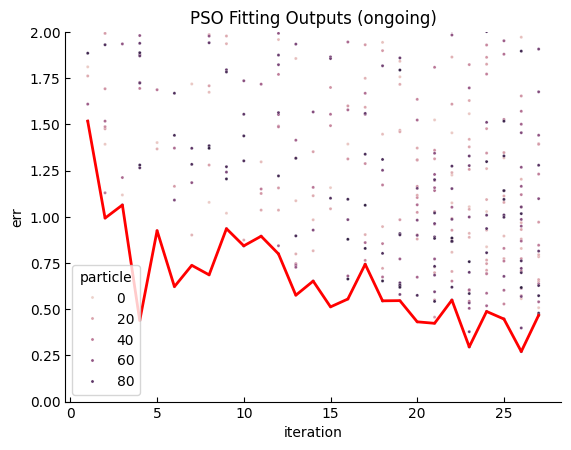

In [23]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="err", hue="particle", s=5)
plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("err")
plt.xlabel("iteration")
plt.ylim([0, 2])
# ax.legend().set_visible(False)
plt.title(f"PSO Fitting Outputs ({FIT_SOURCE})")
plt.show()

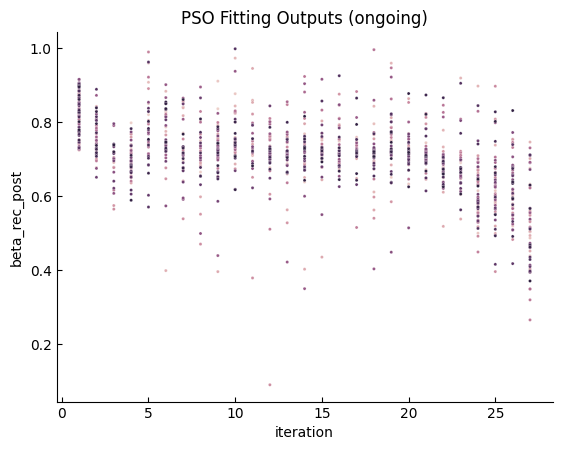

In [24]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="para", hue="particle", s=5)
plt.ylabel(PARAM_NAME)
plt.xlabel("iteration")
# plt.ylim([400000, 600000])
ax.legend().set_visible(False)
plt.title(f"PSO Fitting Outputs ({FIT_SOURCE})")
plt.show()